# **Project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


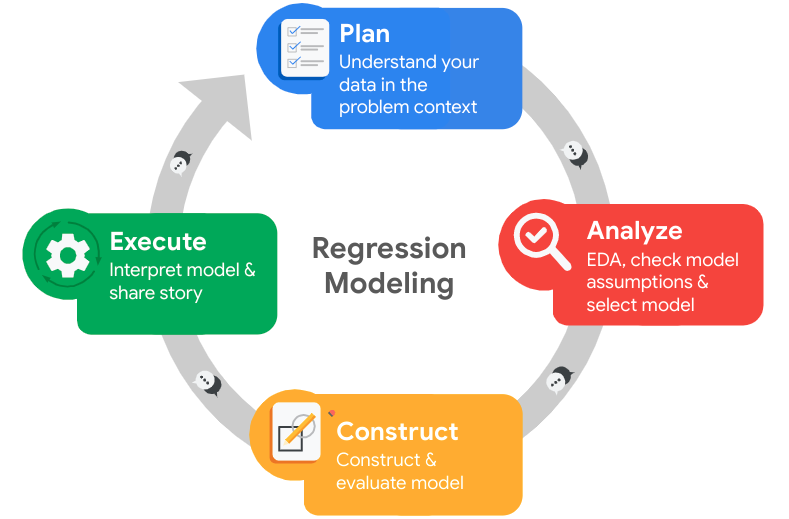

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




## PACE Framework | Stage 1: Plan

---

## 1. Stakeholders
- **HR Department** — Primary client; wants to understand attrition drivers
- **Senior Leadership** — Interested in reducing hiring costs
- **Department Managers** — Need visibility into at-risk team members
- **Employees** — Indirectly affected by resulting policy changes

---

## 2. Objective
Build a **binary classification model** to predict whether an employee will leave (`left` = 1 or 0), and identify the key features driving attrition — enabling HR to intervene proactively and reduce turnover costs.

---

## 3. Initial Observations
- **Mixed data types:** continuous, binary, and categorical variables present
- **Potential class imbalance:** attrition datasets typically have more "stayed" than "left" records
- **Likely correlation:** `number_project` and `average_monthly_hours` may be collinear
- **`salary`** appears ordinal (low/medium/high), requiring encoding
- **`satisfaction_level`** is self-reported — possible response bias

---

## 4. Resources
| Resource | Link |
|---|---|
| pandas docs | https://pandas.pydata.org/docs/ |
| scikit-learn docs | https://scikit-learn.org/stable/ |
| Seaborn docs | https://seaborn.pydata.org/ |
| Kaggle HR Dataset | https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction |

---

## 5. Ethical Considerations
- **Privacy:** Employee data is sensitive; access should be restricted
- **Fairness:** Check if `Department` or `salary` proxy for protected attributes
- **Misuse:** Model should support HR decisions, not replace human judgment
- **Consent:** Employees may be unaware their data is used for modeling

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
print(df0.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
print(df0.columns.tolist())

['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


In [6]:
# Rename columns as needed
### YOUR CODE HERE ###

df0.columns = [c.lower() for c in df0.columns]

# Display all column names after the update
### YOUR CODE HERE ###
print(f'columns name after rename {df0.columns.tolist()}')

columns name after rename ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary']


### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###
df0.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
n_dup = df0.duplicated().sum()
print(f'The duplicated rows found {n_dup} ({n_dup/len(df0)*100:.2f}%)')

The duplicated rows found 3008 (20.05%)


In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()].head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df_clean = df0.drop_duplicates(keep='first')
print(f'shape before: {df0.shape} -> shape after: {df_clean.shape}')
# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df_clean.head()

shape before: (14999, 10) -> shape after: (11991, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

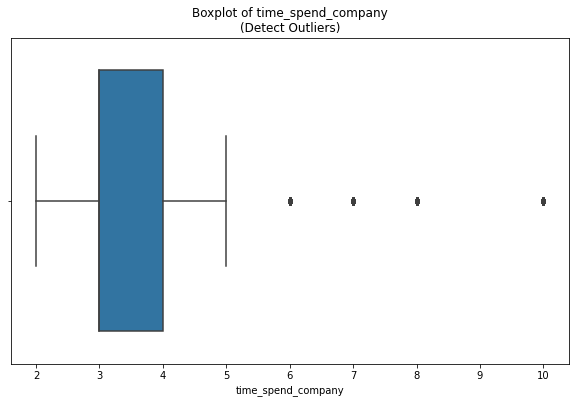

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize = (10,6))
sns.boxplot(x = 'time_spend_company', data = df_clean)
plt.title('Boxplot of time_spend_company\n(Detect Outliers)')
plt.show()

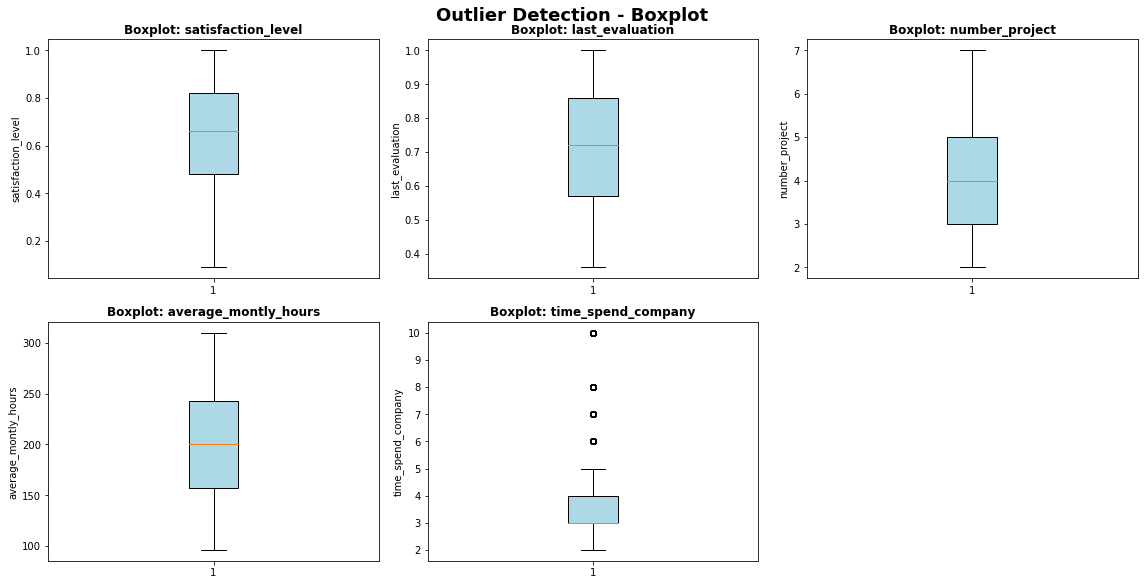

In [12]:
numeric_cols = df_clean.columns[0:5]
fig, axes = plt.subplots(2,3, figsize =(16,8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], vert = True, patch_artist = True,
                   boxprops =dict(facecolor = 'lightblue'))
    axes[i].set_title(f'Boxplot: {col}', fontweight = 'bold')
    axes[i].set_ylabel(col)
    
axes[5].axis('off')
plt.suptitle('Outlier Detection - Boxplot', fontsize =18, fontweight ='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
print('=== Outliers Summary (IQR Method)===\n')
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    n_outliers = df_clean[(df_clean[col]<lower) | (df_clean[col]>upper)].shape[0]
    pct = n_outliers / len(df_clean) * 100
    print(f'{col:28s} -> Outliers : {n_outliers:4d} ({pct:.2f}%)')

=== Outliers Summary (IQR Method)===

satisfaction_level           -> Outliers :    0 (0.00%)
last_evaluation              -> Outliers :    0 (0.00%)
number_project               -> Outliers :    0 (0.00%)
average_montly_hours         -> Outliers :    0 (0.00%)
time_spend_company           -> Outliers :  824 (6.87%)


Why: Boxplots visually expose outliers; IQR method quantifies them. For `time_spend_company`, very long-tenured employees (e.g., 10+ years) may skew tree models. 
* Decision: The outliers are real (not data entry errors), keep them — they represent genuine edge cases the model should learn from.

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

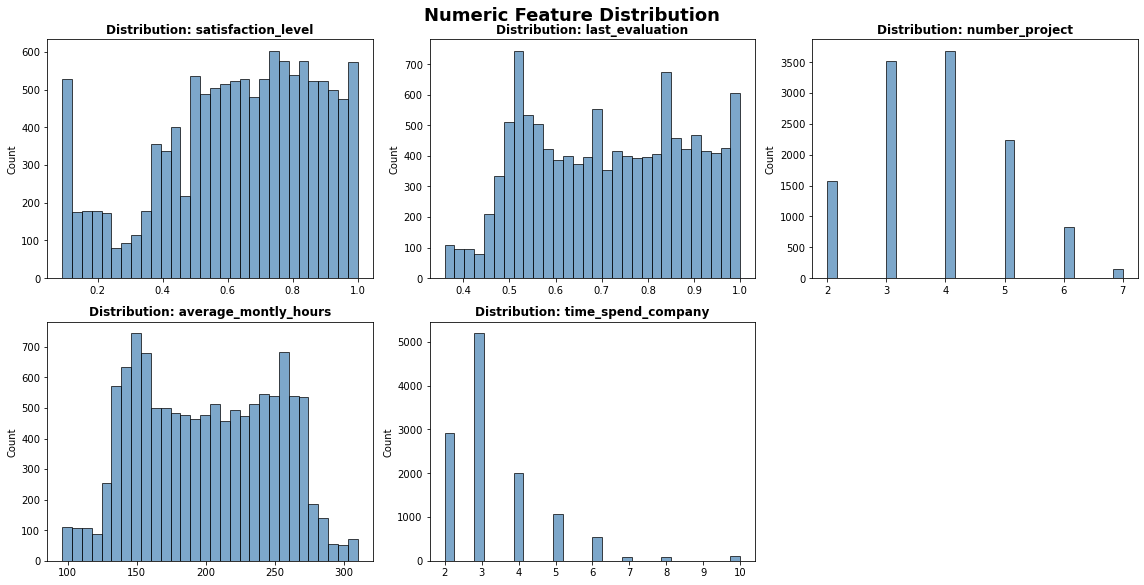

In [14]:
fig , ax = plt.subplots(2,3, figsize =(16,8))
ax = ax.flatten() 

for i, col in enumerate(numeric_cols):
    ax[i].hist(df_clean[col], bins = 30, color = 'steelblue', edgecolor ='black', alpha =0.7)
    ax[i].set_title(f'Distribution: {col}', fontweight ='bold')
    ax[i].set_ylabel('Count')
    
ax[5].axis('off')
plt.suptitle('Numeric Feature Distribution', fontsize = 18, fontweight ='bold', y=1.01)
plt.tight_layout()
plt.show()

Why: Reveals skewness, bimodal patterns, or impossible values. For example, a bimodal distribution in satisfaction_level would suggest two distinct employee groups — a major insight.

In [15]:
print("=" * 45)
print("       CLEANED DATASET SUMMARY")
print("=" * 45)
print(f"  Rows (employees)     : {df_clean.shape[0]:,}")
print(f"  Columns (features)   : {df_clean.shape[1]}")
print(f"  Missing values       : {df_clean.isnull().sum().sum()}")
print(f"  Duplicates removed   : {df0.shape[0] - df_clean.shape[0]:,}")
print(f"  Employees who left   : {df_clean['left'].sum():,} ({df_clean['left'].mean()*100:.1f}%)")
print(f"  Employees who stayed : {(df_clean['left']==0).sum():,} ({(df_clean['left']==0).mean()*100:.1f}%)")
print("=" * 45)
print("\n✅ Ready for Stage 2: Analyze Stage")

       CLEANED DATASET SUMMARY
  Rows (employees)     : 11,991
  Columns (features)   : 10
  Missing values       : 0
  Duplicates removed   : 3,008
  Employees who left   : 1,991 (16.6%)
  Employees who stayed : 10,000 (83.4%)

✅ Ready for Stage 2: Analyze Stage


# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [16]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
left_count = df_clean['left'].value_counts()
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
left_pct = df_clean['left'].value_counts(normalize = True) * 100

print(left_count)
print(f'\nStayed: {left_pct[0]:.1f}% | Left: {left_pct[1]:.1f}%')

0    10000
1     1991
Name: left, dtype: int64

Stayed: 83.4% | Left: 16.6%


Why: Class imbalance (e.g., 83% stayed / 17% left) is critical to detect early. If severe, accuracy becomes a misleading metric — a model predicting "everyone stays" would score 83% accuracy but be useless. We'd then need SMOTE, class weights, or use F1/AUC-ROC instead of accuracy.

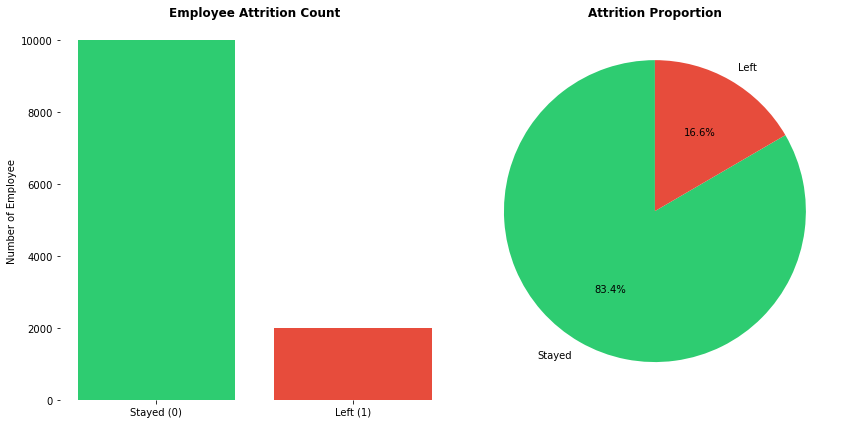

In [17]:
fig, ax = plt.subplots(1,2, figsize = (12,6))

ax[0].bar(['Stayed (0)','Left (1)'], left_count, color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Employee Attrition Count', fontweight = 'bold')
ax[0].set_ylabel('Number of Employee')
for spine in ax[0].spines.values():
    spine.set_visible(False)
ax[1].pie(left_count, labels =['Stayed', 'Left'], autopct ='%1.1f%%',
         colors = ['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Attrition Proportion', fontweight ='bold')

plt.tight_layout()
plt.show()

**Attrition Baseline**
~17% of employees left — mild class imbalance, will be addressed in modeling with `class_weight='balanced'`.

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

* **Attrition by Department & Salary**
Categorical features like department and salary can reveal structural retention problems. If certain departments or pay bands drive disproportionate attrition, HR can target interventions precisely.

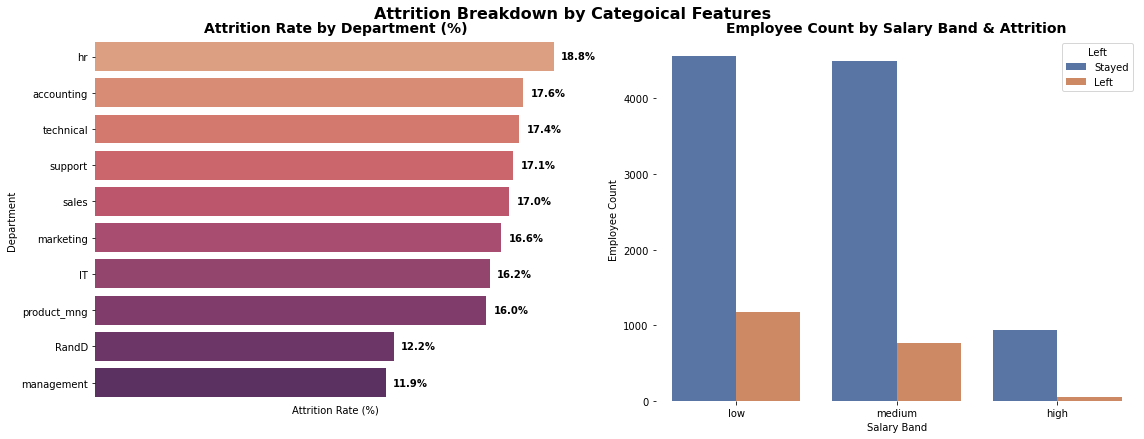

In [18]:
fig, axes = plt.subplots(1,2, figsize = (16,6))

#---Department---
dept_attrition = (df_clean.groupby('department')['left']
    .mean()
    .mul(100)
    .sort_values(ascending = False)
    .reset_index()
    .rename(columns ={'left':'attrition_rate'}))
    
sns.barplot(
    data = dept_attrition, x ='attrition_rate', y = 'department',palette ='flare', ax =axes[0]
)
axes[0].set_title('Attrition Rate by Department (%)', fontsize = 14, fontweight ='bold')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_ylabel('Department')
axes[0].set_xticks([])
for spine in axes[0].spines.values():
    spine.set_visible(False)
for patch,val in zip(axes[0].patches, dept_attrition['attrition_rate']):
    axes[0].text(
    patch.get_width() +0.3,
    patch.get_y() + patch.get_height()/2,
    f'{val:.1f}%',
    va ='center', fontsize = 10, fontweight ='bold')

#---- Salary ----
sns.countplot(data = df_clean,
             x ='salary', hue ='left',
             palette = {0:'#4C72B0', 1: '#DD8452'},
             ax = axes[1])
axes[1].set_title('Employee Count by Salary Band & Attrition', fontsize =14, fontweight='bold')
axes[1].set_xlabel('Salary Band')
axes[1].set_ylabel('Employee Count')
axes[1].legend(title='Left', labels=['Stayed','Left'])
for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.suptitle('Attrition Breakdown by Categoical Features', fontsize = 16, fontweight ='bold',y =1.01)
plt.tight_layout()
plt.show()

* **Attrition Rate by Tenure**
: Tenure is ordinal and time-sensitive. A bar chart of attrition rate per year pinpoints the exact retention window HR should target, which a distribution histogram cannot show clearly.

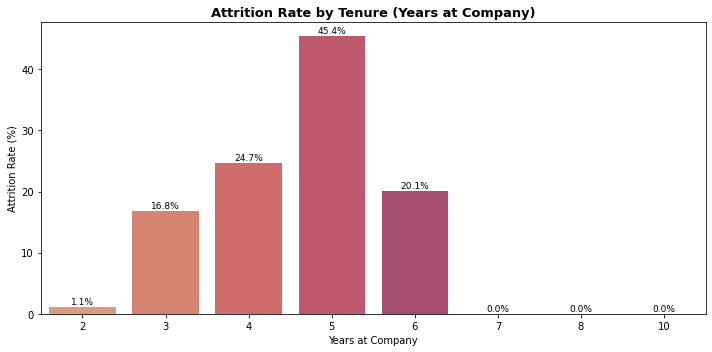

In [19]:
# ── Attrition Rate by Tenure (time_spend_company) ──────────────────────────
tenure_attrition = (
    df_clean.groupby('time_spend_company')['left']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'left': 'attrition_rate'})
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=tenure_attrition,
    x='time_spend_company', y='attrition_rate',
    palette='flare'
)

for patch, val in zip(ax.patches, tenure_attrition['attrition_rate']):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontsize=9
    )

plt.title('Attrition Rate by Tenure (Years at Company)', fontsize=13, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

**Tenure**
Attrition peaks at **year 5 (45.4%)** then drops sharply. Employees past year 6 are highly stable.
> 🎯 Years 3–5 are the critical retention window.


* **Binary Features vs. Attrition**
`work_accident` and `promotion_last_5years` are binary flags never directly compared against `left`. Visualizing their attrition rates tests two critical HR hypotheses — whether accidents drive attrition and whether lack of promotion does.


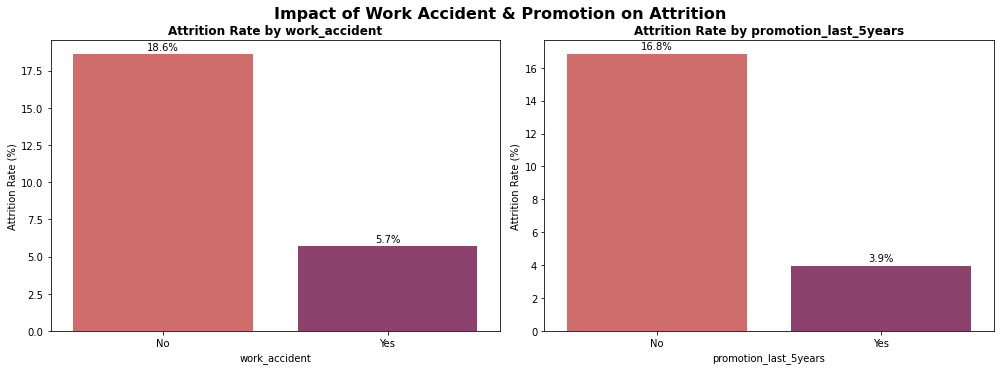

In [20]:
#-- Binary Features vs. Attrition---
binary_features = ['work_accident', 'promotion_last_5years']
labels_map = {0:'No', 1:'Yes'}

fig, axes = plt.subplots(1,2, figsize = (14,5))

for ax, feature in zip(axes, binary_features):
    binary_attrition = (
    df_clean.groupby(feature)['left']
    .mean().mul(100).reset_index().rename(columns ={'left':'attrition_rate', feature:'value'}))
    
    binary_attrition['value'] = binary_attrition['value'].map(labels_map)
    sns.barplot(data = binary_attrition,
               x ='value', y='attrition_rate',
               palette ='flare', ax =ax)
    
    for patch, val in zip(ax.patches, binary_attrition['attrition_rate']):
        ax.text(patch.get_x()+ patch.get_width()/2,
               patch.get_height()+0.3,
               f'{val:.1f}%', ha ='center', fontsize = 10)
        
    ax.set_title(f'Attrition Rate by {feature}', fontsize =12, fontweight ='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Attrition Rate (%)')
plt.suptitle('Impact of Work Accident & Promotion on Attrition',
            fontsize = 16, fontweight ='bold', y=1.02)
plt.tight_layout()
plt.show()

**Compensation & Career Growth**
- Low-salary employees leave at significantly higher rates than medium/high.
- Employees **not promoted** leave at **4× the rate** of those who were (16.8% vs. 3.9%).

---

**Work Accident**
Employees who experienced a work accident churn *less* (5.7% vs. 18.6%) —
possibly reflecting stronger company support post-incident.


* **Attrition Rate by Number of Projects**
: Project count is ordinal — treating it as a bar chart of attrition rate per level reveals a threshold effect that a scatter plot obscures. This is directly actionable for HR: it pinpoints the project load at which attrition sharply spikes.

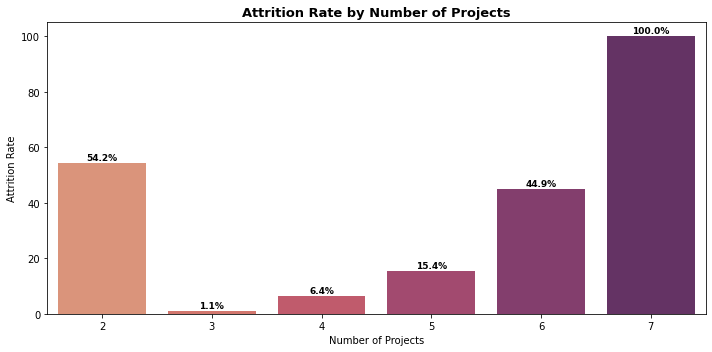

In [21]:
project_attrition = (df_clean.groupby('number_project')['left'].mean().mul(100).
                    reset_index().rename(columns = {'left':'attrition_rate'}))

plt.figure(figsize = (10,5))
ax = sns.barplot(data= project_attrition,
                x ='number_project', y ='attrition_rate',
                 palette ='flare')

for patch, val in zip(ax.patches, project_attrition['attrition_rate']):
    ax.text(patch.get_x() + patch.get_width()/2,
           patch.get_height() + 1,
           f'{val:.1f}%', ha ='center', fontsize = 9,fontweight ='bold')
plt.title('Attrition Rate by Number of Projects', fontsize =13, fontweight ='bold')
plt.xlabel('Number of Projects')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

**Workload**
Project count follows a **U-shaped attrition curve** — both underloaded (2 projects, 54.2%) and overloaded
(7 projects, 100%) employees leave at extreme rates. Sweet spot is **3–4 projects**.
High monthly hours (250+) combined with low satisfaction is the clearest burnout signal.


* **Feature Distributions: Stayed vs. Left**
: Overlaying distributions by attrition status reveals where the two groups diverge. This directly identifies which numeric features carry the most discriminative signal for the model.

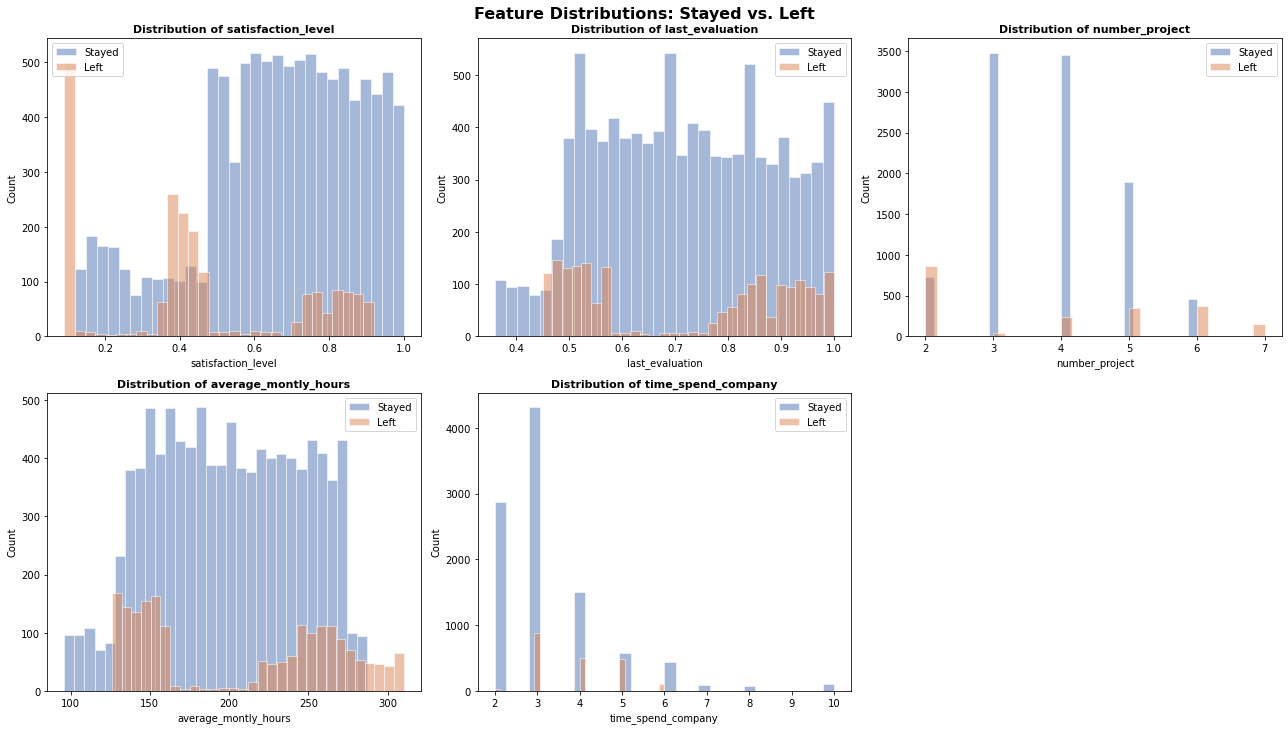

In [22]:
# Create a plot as needed
### YOUR CODE HERE ###
fig, axes = plt.subplots(2,3, figsize = (18,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, group in df_clean.groupby('left'):
        axes[i].hist(
        group[col],
        bins = 30, alpha =0.5,
        label ='Left' if label == 1 else 'Stayed',
        color ='#DD8452' if label ==1 else '#4C72B0',
        edgecolor ='white')
    axes[i].set_title(f'Distribution of {col}', fontsize =11, fontweight ='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend() 
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions: Stayed vs. Left', fontsize = 16, fontweight= 'bold', y =1.01)
plt.tight_layout()
plt.show()

* **Bivariate: Satisfaction vs. Last Evaluation**
: These two continuous variables together can expose employee archetypes — e.g., high performers who are dissatisfied, or low performers coasting. Coloring by `left` reveals whether those archetypes systematically churn.

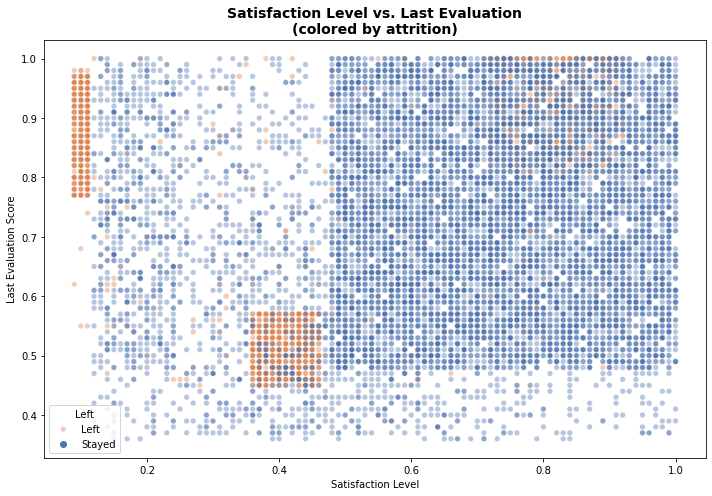

In [23]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize = (10,7))

sns.scatterplot(data = df_clean,
               x ='satisfaction_level', y='last_evaluation',
               hue = 'left',
               palette={0: '#4C72B0', 1: '#DD8452'},
               alpha = 0.4, s=30,
               legend = 'full')
plt.title('Satisfaction Level vs. Last Evaluation\n(colored by attrition)',
         fontsize = 14, fontweight ='bold')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation Score')
plt.legend(title = 'Left',labels = ['Left', 'Stayed'])
plt.tight_layout()
plt.show()

* **Bivariate: Monthly Hours vs. Number of Projects**
: Overwork is a leading attrition driver. Plotting hours against project count, split by `left`, directly tests the hypothesis that employees leave when workload becomes unsustainable.

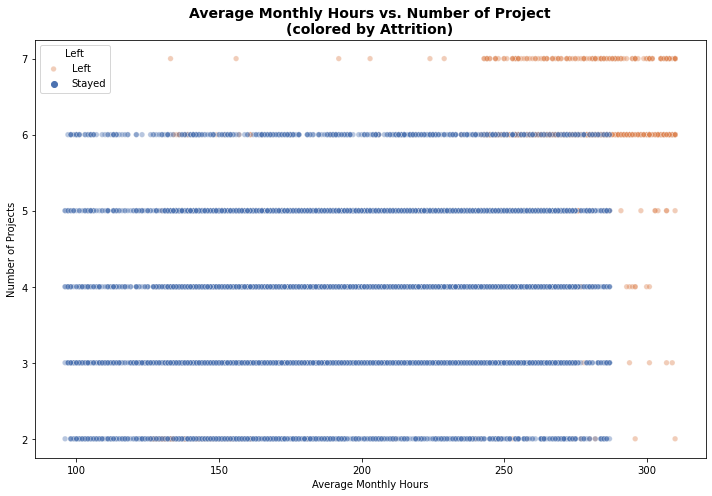

In [24]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize =(10,7))

sns.scatterplot(data = df_clean,
               x = 'average_montly_hours',
               y = 'number_project',
               hue = 'left',
               palette = {0: '#4C72B0', 1: '#DD8452'},
               alpha = 0.4, s = 30)

plt.title('Average Monthly Hours vs. Number of Project\n(colored by Attrition)',
         fontsize = 14, fontweight ='bold')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Number of Projects')
plt.legend(title ='Left', labels = ['Left', 'Stayed'])
plt.tight_layout()
plt.show()

* **Monthly Hours vs. Satisfaction colored by Attrition**
: This is the most direct test of the burnout hypothesis. Plotting hours against satisfaction, colored by left, should visually confirm whether the overworked-and-dissatisfied cluster drives the majority of attrition.


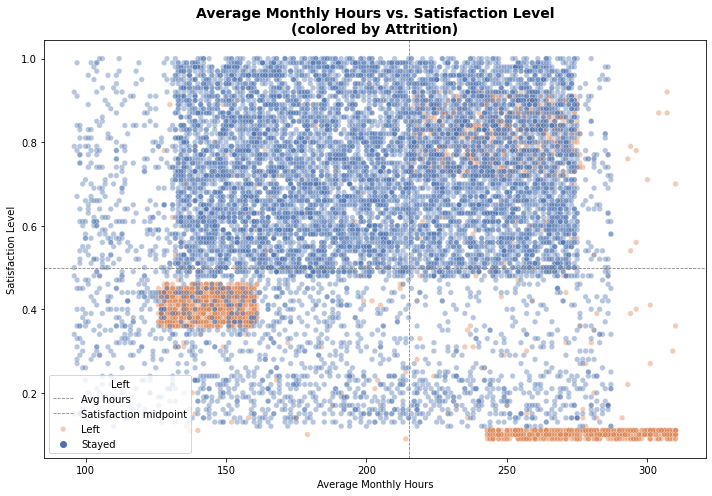

In [25]:
plt.figure(figsize = (10,7))

sns.scatterplot(data = df_clean,
               x ='average_montly_hours', y ='satisfaction_level',
               hue = 'left',
               palette = {0: '#4C72B0', 1: '#DD8452'}, alpha = 0.4, s=30)

#Annotate key quadrants
plt.axvline(x =215, color ='gray', linestyle='--', linewidth=0.8, label='Avg hour threshold')
plt.axhline(y =0.5, color ='gray', linestyle='--', linewidth=0.8, label='Satisfaction midpoint')

plt.title('Average Monthly Hours vs. Satisfaction Level\n(colored by Attrition)',
         fontsize = 14, fontweight ='bold')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Satisfaction Level')
plt.legend(title='Left', labels=['Avg hours', 'Satisfaction midpoint','Left', 'Stayed'])
plt.tight_layout()
plt.show()

**Satisfaction & Performance**
Three leaver clusters visible in hours vs. satisfaction scatterplot:

| Cluster | Profile | Signal |
|---|---|---|
| Burned out | 250–300 hrs, satisfaction ~0.0–0.1 | Overwork → burnout |
| Underutilized | 120–150 hrs, satisfaction ~0.4 | Disengagement |
| High performer | 250–300 hrs, satisfaction ~0.7 | Leaving for opportunity |

**Correlation Heatmap**
: The heatmap quantifies linear relationships between all numeric features at once. It flags multicollinearity (problematic for logistic regression) and highlights which features correlate most strongly with `left`.

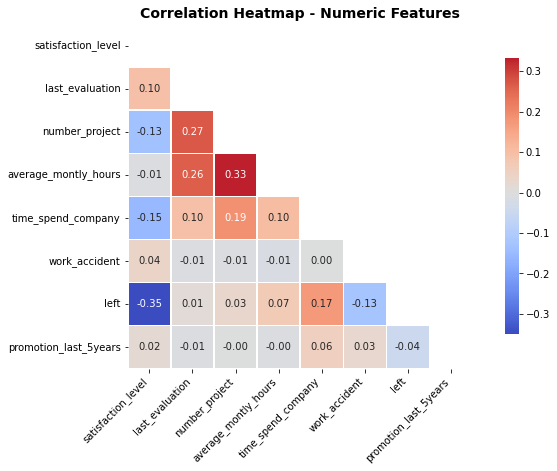

In [26]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize = (10,7))

corr_matrix = df_clean.select_dtypes(include ='number').corr()

mask = np.triu(np.ones_like(corr_matrix, dtype =bool)) # hide upper triangle

sns.heatmap(corr_matrix,
           mask = mask,
           annot = True, fmt ='.2f',
           cmap ='coolwarm', center = 0,
           linewidths =0.5, linecolor ='white',
           square = True, cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap - Numeric Features', fontsize =14, fontweight = 'bold')
plt.tight_layout()
plt.xticks(rotation = 45, ha = 'right')
plt.show()

* **Pairplot (Final EDA Cell)**
The pairplot gives a holistic view — every numeric feature plotted against every other, colored by `left`. It surfaces non-linear patterns and cluster separability that individual bivariate plots might miss.

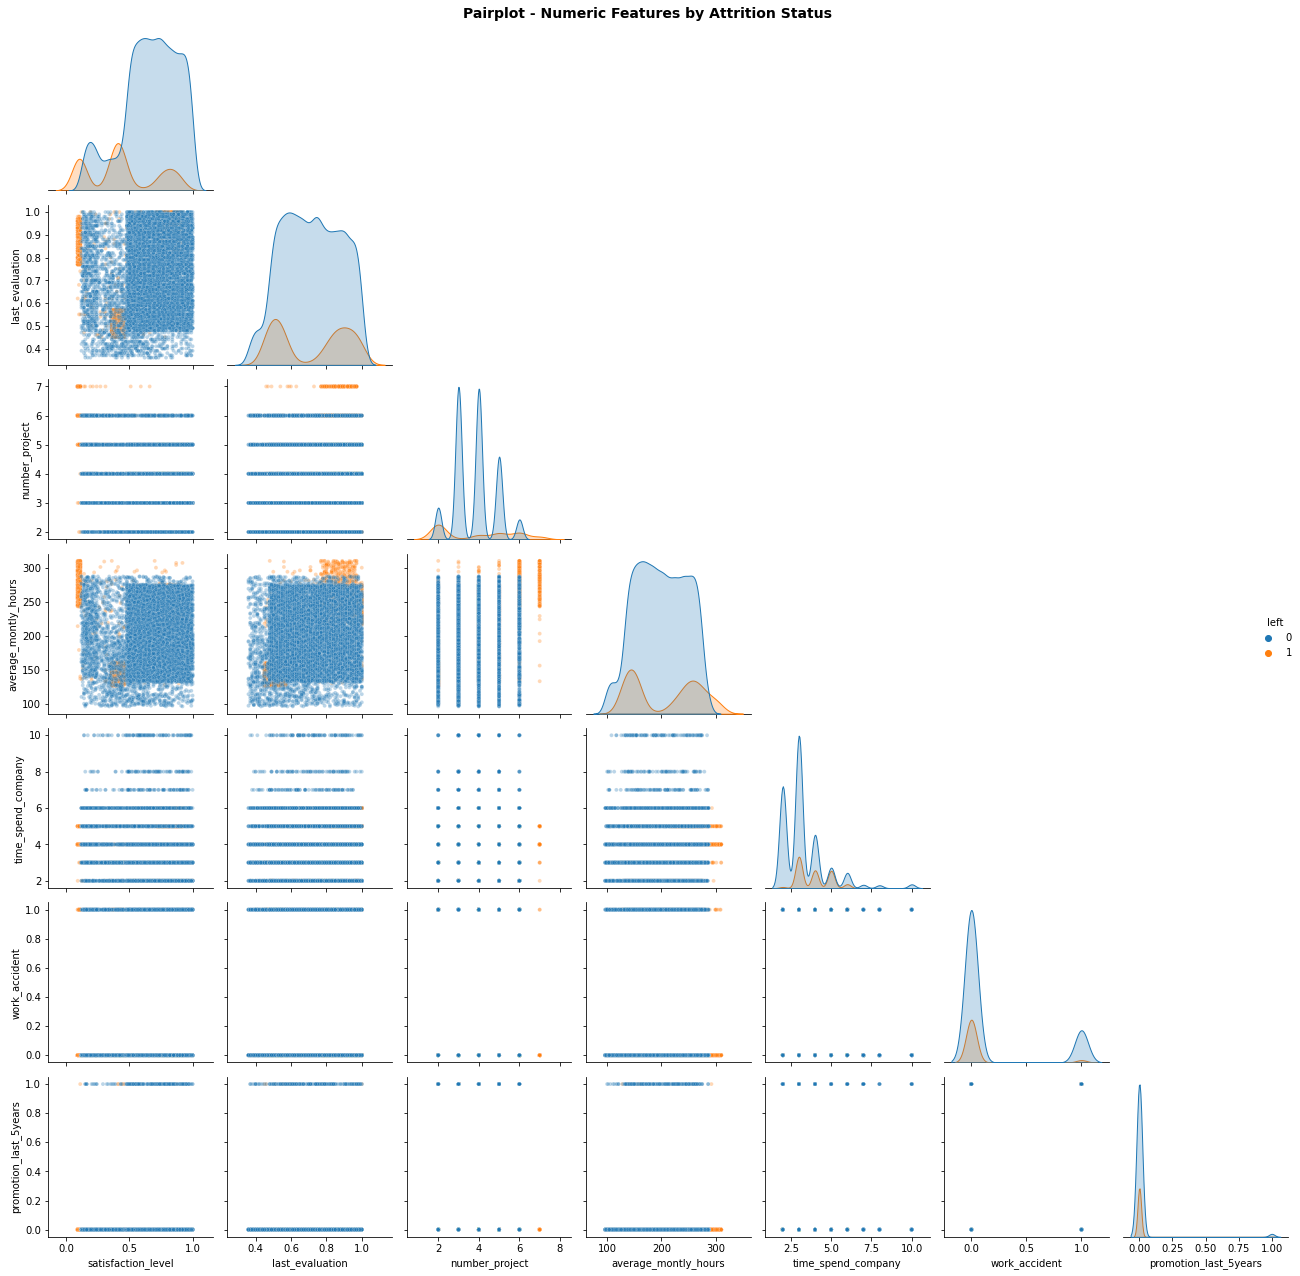

In [27]:
# Create a plot as needed
### YOUR CODE HERE ###
pairplot_features = df_clean.select_dtypes(include ='number').columns

sns.pairplot(df_clean[pairplot_features],
            hue ='left',
            plot_kws ={'alpha' : 0.3, 's':15},
            diag_kind = 'kde',
            corner = True # show lower triangle only, mirrors the heatmap stype
            )
plt.suptitle('Pairplot - Numeric Features by Attrition Status',
            fontsize = 14, fontweight ='bold', y =1.01)
plt.tight_layout()
plt.show()

### Insights

## 📋 Stage 2 — EDA Insights Summary

---

### Key Findings

**1. Attrition Baseline**
~17% of employees left — mild class imbalance, will be addressed in modeling with `class_weight='balanced'`.

---

**2. Tenure**
Attrition peaks at **year 5 (45.4%)** then drops sharply. Employees past year 6 are highly stable.
> 🎯 Years 3–5 are the critical retention window.

---

**3. Workload**
Project count follows a **U-shaped attrition curve** — both underloaded (2 projects, 54.2%) and overloaded
(7 projects, 100%) employees leave at extreme rates. Sweet spot is **3–4 projects**.
High monthly hours (250+) combined with low satisfaction is the clearest burnout signal.

---

**4. Satisfaction & Performance**
Three leaver clusters visible in hours vs. satisfaction scatterplot:

| Cluster | Profile | Signal |
|---|---|---|
| Burned out | 250–300 hrs, satisfaction ~0.0–0.1 | Overwork → burnout |
| Underutilized | 120–150 hrs, satisfaction ~0.4 | Disengagement |
| High performer | 250–300 hrs, satisfaction ~0.7 | Leaving for opportunity |

---

**5. Compensation & Career Growth**
- Low-salary employees leave at significantly higher rates than medium/high.
- Employees **not promoted** leave at **4× the rate** of those who were (16.8% vs. 3.9%).

---

**6. Work Accident**
Employees who experienced a work accident churn *less* (5.7% vs. 18.6%) —
possibly reflecting stronger company support post-incident.

---

### Two Dominant Leaver Archetypes

| | Archetype 1 — Burned Out | Archetype 2 — Disengaged |
|---|---|---|
| **Hours** | 250+ | 120–150 |
| **Projects** | 6–7 | 2 |
| **Satisfaction** | ~0.0–0.1 | ~0.4 |
| **Tenure** | 3–5 years | Varies |
| **Salary** | Low | Low–Medium |
| **Promoted** | No | No |

---

### Modeling Implications

- **Algorithm:** Tree-based models preferred — data is non-normal with non-linear patterns.
- **Class imbalance:** Use `class_weight='balanced'` and stratified train/test split.
- **Priority features:** `satisfaction_level`, `number_project`, `average_monthly_hours`,
`time_spend_company`, `salary`, `promotion_last_5years`.

---

> ✅ **Stage 2 Complete — Proceeding to Stage 3 (Construct): Feature Engineering & Model Building.**

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

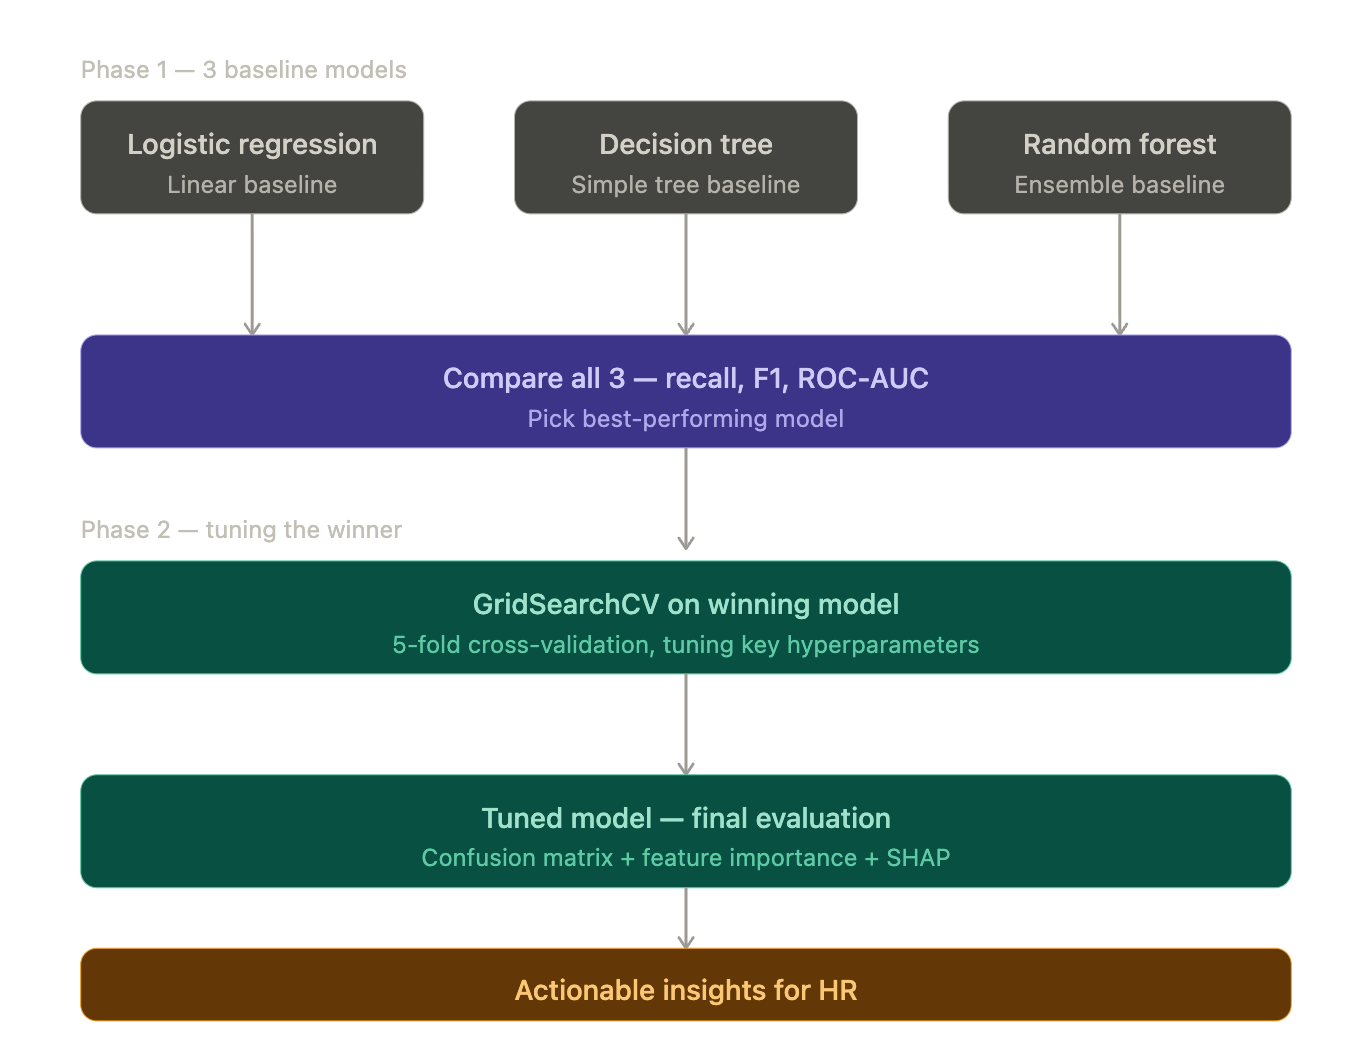

### Identify the types of models most appropriate for this task.

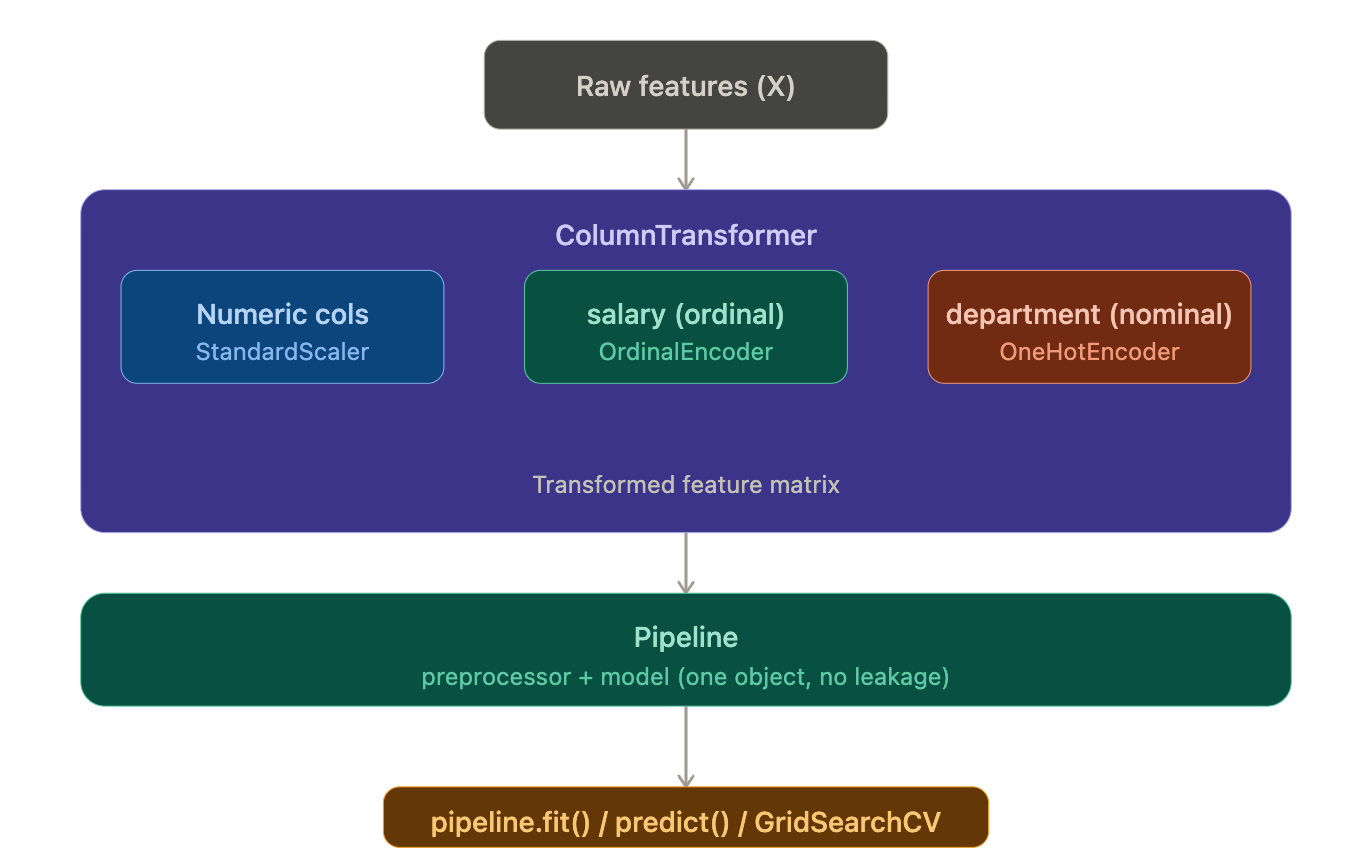

### Modeling

Add as many cells as you need to conduct the modeling process.

In [28]:
### YOUR CODE HERE ###
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded.")

Libraries loaded.


**Feature Engineering + Define Column Groups**
: We still add hours_per_project manually (it's a domain-knowledge feature, not a transformation). Then we declare which columns belong to each transformer track.


In [29]:
# Feature Engineering
df_model = df_clean.copy()

# Domain Feature: burnout signal from EDA
df_model['hours_per_project'] = (df_model['average_montly_hours'] / 
                                 df_model['number_project'])

# Columns Group
numeric_cols = [col for col in df_model.select_dtypes(include='number').columns if col != 'left']
ordinal_cols = ['salary']
nominal_cols = ['department']

print('Numeric :', numeric_cols)
print('ordinal :', ordinal_cols)
print('Nominal :', nominal_cols)

Numeric : ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident', 'promotion_last_5years', 'hours_per_project']
ordinal : ['salary']
Nominal : ['department']


**Train / Test Split**
: Split before building the preprocessor so transformers are fit only on training data — no leakage.

In [30]:
# Train/Test Split
X = df_model.drop(columns =['left'])
y = df_model['left']

X_train, X_test, y_train, y_test =train_test_split(X, y, test_size =0.20, 
                                                   stratify = y, random_state =42)

print(f'Train : {X_train.shape[0]:,} rows')
print(f'Test : {X_test.shape[0]:,} rows')
print(f'\nClass balance - train:\n{y_train.value_counts(normalize = True).round(3)}')

Train : 9,592 rows
Test : 2,399 rows

Class balance - train:
0    0.834
1    0.166
Name: left, dtype: float64


**Build the ColumnTransformer + Preprocessor**
: One object that routes each column group to the correct transformer. remainder='drop' ensures no column sneaks through untransformed.


In [31]:
# Preprocessor
preprocessor = ColumnTransformer(transformers =[
    ('num', StandardScaler(),numeric_cols),
    ('ord', OrdinalEncoder(categories=[['low','medium','high']], # enforce correct order
                          ), ordinal_cols),
    ('nom', OneHotEncoder(drop ='first',
                         handle_unknown ='error',
                         sparse= False), nominal_cols)
], remainder = 'drop')

**Build the 3 Baseline Pipelines**
Why: Each pipeline = preprocessor + model. Calling .fit() on the pipeline triggers preprocessing and training in one safe step.

In [32]:
# Baseline Pipeline
pipeline = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(class_weight ='balanced',
                                  max_iter=1000, random_state=42))]),
    'Decision Tree': Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(class_weight='balanced',
                                      random_state = 42))]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators = 100,
                                      class_weight = 'balanced',
                                      random_state = 42, n_jobs=-1))])
    
}

# Train all 3 models 
for name, pipe in pipeline.items():
    pipe.fit(X_train, y_train)
    print(f'{name} - trained')

Logistic Regression - trained
Decision Tree - trained
Random Forest - trained



  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.96      0.77      0.86      2001
        Left       0.42      0.84      0.56       398

    accuracy                           0.78      2399
   macro avg       0.69      0.81      0.71      2399
weighted avg       0.87      0.78      0.81      2399

ROC-AUC : 0.8512
Recall  : 0.8417
F1      : 0.5644


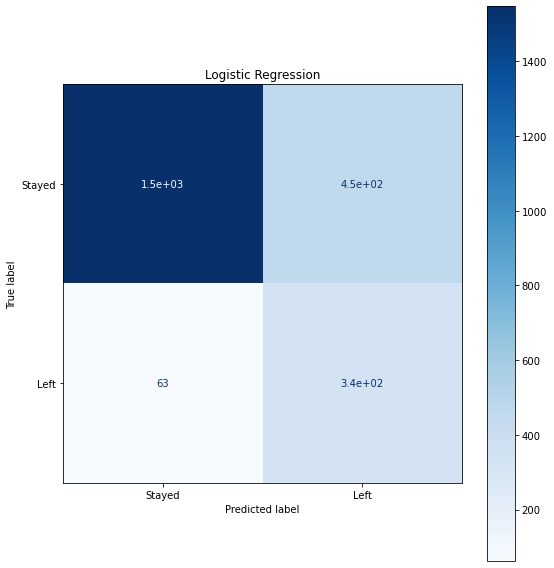


  Decision Tree
              precision    recall  f1-score   support

      Stayed       0.99      0.98      0.98      2001
        Left       0.90      0.93      0.91       398

    accuracy                           0.97      2399
   macro avg       0.94      0.95      0.95      2399
weighted avg       0.97      0.97      0.97      2399

ROC-AUC : 0.9536
Recall  : 0.9271
F1      : 0.9145


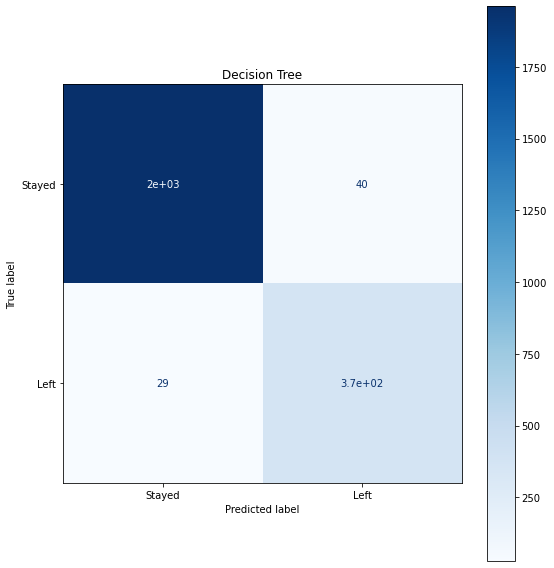


  Random Forest
              precision    recall  f1-score   support

      Stayed       0.98      1.00      0.99      2001
        Left       0.99      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.98      0.98      2399

ROC-AUC : 0.9799
Recall  : 0.9196
F1      : 0.9531


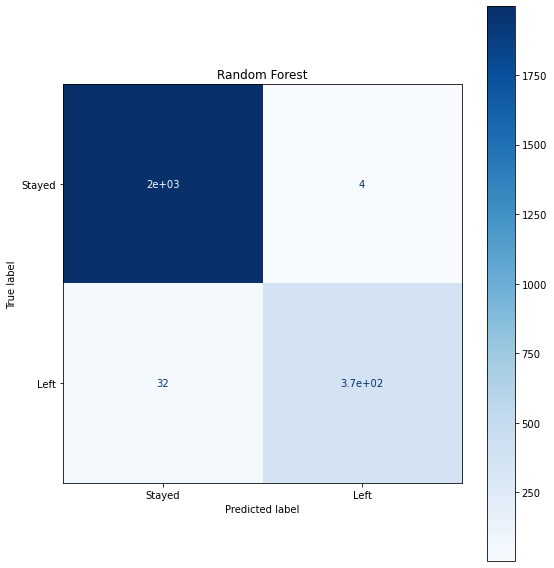

In [33]:
# ── Evaluation Helper ─────────────────────────────────────────────────
def evaluate_model(name, pipeline, X_test_, y_test_):
    y_pred = pipeline.predict(X_test_)
    y_prob = pipeline.predict_proba(X_test_)[:, 1]

    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_test_, y_pred, target_names=['Stayed', 'Left']))
    print(f"ROC-AUC : {roc_auc_score(y_test_, y_prob):.4f}")
    print(f"Recall  : {recall_score(y_test_, y_pred):.4f}")
    print(f"F1      : {f1_score(y_test_, y_pred):.4f}")

    fig, ax = plt.subplots(figsize=(8, 8))
    cm = confusion_matrix(y_test_, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Stayed', 'Left']
)
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

# ── Run evaluations ───────────────────────────────────────────────────
for name, pipe in pipeline.items():
    evaluate_model(name, pipe, X_test, y_test)

In [34]:
results = []
for name, pipe in pipeline.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    results.append({
        'Model': name,
        'Recall': round(recall_score(y_test,y_pred),4),
        'F1': round(f1_score(y_test, y_pred),4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob),4),
        'Accuray': round(accuracy_score(y_test, y_pred),4)
    })
df_results = pd.DataFrame(results).set_index('Model')
print(df_results.to_string())

                     Recall      F1  ROC-AUC  Accuray
Model                                                
Logistic Regression  0.8417  0.5644   0.8512   0.7845
Decision Tree        0.9271  0.9145   0.9536   0.9712
Random Forest        0.9196  0.9531   0.9799   0.9850


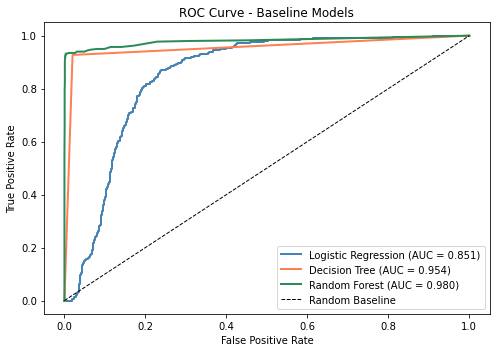

In [35]:
from sklearn.metrics import roc_curve

plt.figure(figsize = (7,5))
colors = ['steelblue','coral','seagreen']

for (name, pipe), color in zip(pipeline.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label =f'{name} (AUC = {auc:.3f})', color=color, lw =2)
    
# Random Baseline
plt.plot([0,1],[0,1], 'k--', lw=1, label ='Random Baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Models')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

## Model Selection — Random Forest

Three baseline models were evaluated on the test set: Logistic Regression, Decision Tree, and Random Forest.
While the Decision Tree achieved a marginally higher recall (0.9271 vs 0.9196), this advantage is threshold-dependent
and comes at the cost of significantly lower precision, reflected in its weaker F1-score (0.9145 vs 0.9531).

Random Forest demonstrated superior overall discrimination with a ROC-AUC of 0.9799 versus 0.9536,
meaning it better separates leavers from stayers across all classification thresholds — not just at the default 0.5 cutoff.
Its higher F1-score also indicates that when it flags an employee as at-risk, the prediction is more trustworthy,
reducing wasted HR effort on false alarms.

For these reasons, **Random Forest was selected as the final model** for hyperparameter tuning via GridSearchCV,
with recall as the primary optimization metric to minimize the cost of missing at-risk employees.

In [36]:
# GridSearchCV: Random Forest Pipeline
param_grid = {
    'clf__n_estimators' : [100,200],
    'clf__max_depth' : [None, 10, 20],
    'clf__min_samples_split' : [2,5],
    'clf__min_samples_leaf' : [1,2]
}

grid_search = GridSearchCV(estimator = pipeline['Random Forest'],
                          param_grid=param_grid,
                          scoring ='recall',
                          cv =5, verbose =1, n_jobs =-1)

grid_search.fit(X_train, y_train)

print('\nBest parameters:', grid_search.best_params_)
print(f'Best CV recall: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:  2.0min finished



Best parameters: {'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Best CV recall: 0.9090



  Random Forest (Tuned)
              precision    recall  f1-score   support

      Stayed       0.98      1.00      0.99      2001
        Left       0.99      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.98      0.98      2399

ROC-AUC : 0.9792
Recall  : 0.9221
F1      : 0.9532


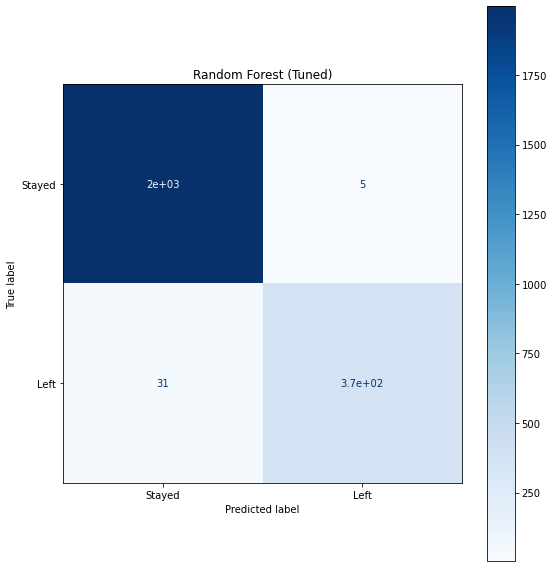

In [37]:
# Final Tuned Model Evaluation
best_pipeline = grid_search.best_estimator_
evaluate_model('Random Forest (Tuned)', best_pipeline, X_test,y_test)

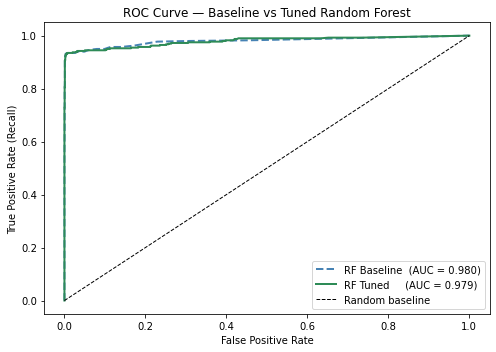

In [38]:
# ── ROC Curve: Baseline vs Tuned RF ──────────────────────────────────
plt.figure(figsize=(7, 5))

# Baseline RF
y_prob_base = pipeline["Random Forest"].predict_proba(X_test)[:, 1]
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
auc_b = roc_auc_score(y_test, y_prob_base)
plt.plot(fpr_b, tpr_b, label=f"RF Baseline  (AUC = {auc_b:.3f})",
         color='steelblue', lw=2, linestyle='--')

# Tuned RF
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
auc_t = roc_auc_score(y_test, y_prob_tuned)
plt.plot(fpr_t, tpr_t, label=f"RF Tuned     (AUC = {auc_t:.3f})",
         color='seagreen', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Baseline vs Tuned Random Forest")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Stage 3 Construct — Summary

The goal of this stage was to build and validate a classification model capable of predicting employee attrition.

Three baseline models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.
Random Forest was selected as the final model based on its superior ROC-AUC (0.9799) and F1-score (0.9531),
reflecting stronger overall discrimination and more reliable predictions compared to the other candidates.

Hyperparameter tuning via GridSearchCV with 5-fold cross-validation yielded marginal improvements,
confirming that the baseline Random Forest was already well-configured and robust.
The tuned model achieved a Recall of 0.9221, F1 of 0.9532, and ROC-AUC of 0.9792 on the held-out test set.

The model is now ready for interpretation and communication in **Stage 4 — Execute**.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




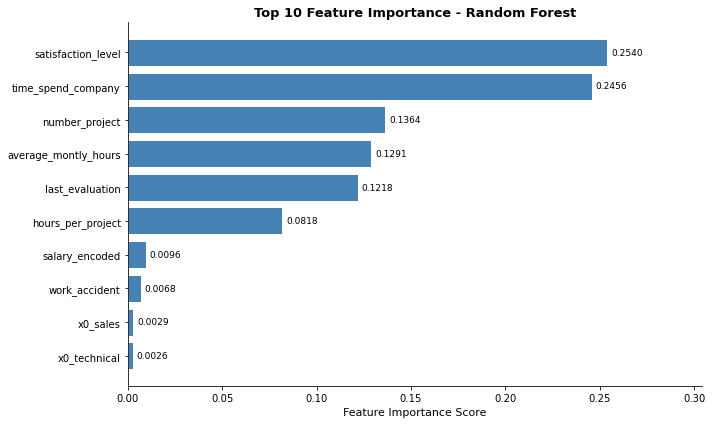

In [39]:
# Extract the trained classifier and preprocessor from the pipeline
clf = best_pipeline.named_steps['clf']
pre_processor = best_pipeline.named_steps['pre']

# Reconstruct feature name after preprocessing

nom_cols = pre_processor.named_transformers_['nom'].get_feature_names()
ord_cols = ['salary_encoded']
all_features = numeric_cols + ord_cols + list(nom_cols) 

# Extract improtance scores
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

top_features = [all_features[i] for i in indices]
top_scores = importances[indices]

# Plot
fig, ax = plt.subplots(figsize = (10,6))
bars = ax.barh(top_features[::-1], top_scores[::-1], color ='steelblue', edgecolor = 'white')

# Manual annotation 
for bar, score in zip(bars, top_scores[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
           f'{score:.4f}',va='center', ha='left', fontsize =9)
ax.set_xlabel('Feature Importance Score', fontsize = 11)
ax.set_title('Top 10 Feature Importance - Random Forest', fontsize = 13, fontweight ='bold')
ax.set_xlim(0, top_scores.max() +0.05)
sns.despine()
plt.tight_layout()
plt.show()

### Summary of model results

## Stage 4 — Execute 

### What Drives Employee Attrition?
Based on the Random Forest model's feature importance scores, combined with EDA findings,
the following factors are the strongest predictors of employee attrition.

---

### Top Model Drivers
| Rank | Feature | Business Meaning |
|------|---------|-----------------|
| 1 | `satisfaction_level` | Strongest single predictor — dissatisfied employees leave |
| 2 | `time_spend_company` | Tenure is a critical risk window, peaks at year 5 |
| 3 | `average_monthly_hours` | High workload volume is a burnout signal |
| 4 | `number_project` | Too few or too many projects both drive attrition |
| 5 | `last_evaluation` | High performers leave when unrewarded |

---

### Two Leaver Archetypes

**Archetype 1 — The Burned Out Employee**
- 250–300 monthly hours, 6–7 projects
- Satisfaction near 0.0, high evaluation score
- No promotion in 5 years
- **Interpretation:** Overworked high performers with no career recognition eventually quit despite strong output.

**Archetype 2 — The Disengaged Employee**
- 120–150 monthly hours, only 2 projects
- Satisfaction ~0.4, no promotion
- **Interpretation:** Underutilized employees who feel overlooked drift toward quiet departure.

---

### Highest Risk Segments
- **Tenure year 3–5** — attrition peaks at year 5 (45.4%)
- **Low salary** — significantly higher attrition than medium/high
- **No promotion** — 4× higher attrition vs. promoted employees
- **7 projects** — 100% attrition observed in EDA
- **2 projects** — 54.2% attrition observed in EDA

### Conclusion, Recommendations, Next Steps

## Stage 4 — Execute 

### Conclusion
The Random Forest model achieved a **ROC-AUC of 0.9792** and **Recall of 0.9221**,
demonstrating strong capability in identifying employees likely to leave.
Analysis reveals that attrition is not random — it is concentrated in predictable
segments driven by workload, satisfaction, tenure, and career progression.

Two distinct leaver archetypes exist:
- **Burned Out** employees who are overworked and unrecognized
- **Disengaged** employees who are underutilized and overlooked

Both groups share one common thread: **no promotion in the last 5 years.**

---

### Recommendations

**1. Address Workload Imbalance**
- Cap individual project assignments at **3–5 projects** per employee
- Flag employees working **250+ monthly hours** for immediate manager review
- Redistribute work from overloaded employees before burnout sets in

**2. Strengthen the Promotion Pipeline**
- Employees with no promotion after 3+ years are at significantly elevated risk
- Implement structured promotion reviews at the **3-year tenure mark**
- Ensure high evaluation scores translate to visible career advancement

**3. Intervene at the Critical Tenure Window (Years 3–5)**
- Attrition peaks sharply at year 5 — this is the highest-risk period
- Launch targeted **retention conversations** at year 3 before dissatisfaction deepens
- Offer role enrichment, mentorship, or lateral growth opportunities proactively

**4. Review Compensation for Low-Salary Employees**
- Low salary is a consistent attrition driver across all departments
- Conduct a **market compensation benchmarking** exercise
- Prioritize salary adjustments for high-performing, low-salary employees

**5. Re-engage Underutilized Employees**
- Employees on only 2 projects show 54.2% attrition — nearly as alarming as overload
- Assign stretch projects or cross-functional responsibilities to boost engagement
- Monitor employees with below-average hours as an early disengagement signal

---

### Next Steps

| Priority | Action | Owner |
|----------|--------|-------|
| High | Deploy model to score current workforce attrition risk | Data Team |
| High | Trigger retention alerts for year 3–5 employees | HR Systems |
| Medium | Integrate workload monitoring into HR dashboard | Engineering |
| Medium | Conduct compensation benchmarking for low-salary band | HR / Finance |
| Low | Re-run model quarterly as new HR data is collected | Data Team |

---

### Limitations & Caveats
- Dataset reflects a snapshot in time — attrition drivers may shift over time
- `left = 1` does not distinguish voluntary resignation from termination
- Work accident's negative correlation with attrition warrants further investigation
- Model should be monitored for drift as workforce composition changes

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.